# PM2.5 Emissions — Exploratory Data Analysis

## Dataset
- **`summarySCC_PM25.rds`** — PM2.5 emissions (tons) per source, county, and year (1999, 2002, 2005, 2008)
- **`Source_Classification_Code.rds`** — Maps SCC codes to human-readable source names

## Questions
1. Have **total US emissions** decreased from 1999 to 2008?
2. Have **Baltimore City** total emissions decreased from 1999 to 2008?
3. Which **source types** in Baltimore City increased/decreased from 1999–2008?
4. How have **coal combustion** emissions changed across the US?
5. How have **motor vehicle** emissions changed in Baltimore City?
6. **Baltimore vs Los Angeles** — which city saw greater change in motor vehicle emissions?

In [1]:
import pyreadr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Read the RDS files
NEI = pyreadr.read_r("summarySCC_PM25.rds")[None]
SCC = pyreadr.read_r("Source_Classification_Code.rds")[None]

# Ensure correct types
NEI["Emissions"] = pd.to_numeric(NEI["Emissions"], errors="coerce")
NEI["year"] = NEI["year"].astype(int)

print("NEI shape:", NEI.shape)
print(NEI.head())
print("\nSCC shape:", SCC.shape)
print(SCC.head())

NEI shape: (6497651, 6)
           fips       SCC Pollutant  Emissions   type  year
rownames                                                   
4         09001  10100401  PM25-PRI     15.714  POINT  1999
8         09001  10100404  PM25-PRI    234.178  POINT  1999
12        09001  10100501  PM25-PRI      0.128  POINT  1999
16        09001  10200401  PM25-PRI      2.036  POINT  1999
20        09001  10200504  PM25-PRI      0.388  POINT  1999

SCC shape: (11717, 15)
        SCC Data.Category                                         Short.Name  \
0  10100101         Point  Ext Comb /Electric Gen /Anthracite Coal /Pulve...   
1  10100102         Point  Ext Comb /Electric Gen /Anthracite Coal /Trave...   
2  10100201         Point  Ext Comb /Electric Gen /Bituminous Coal /Pulve...   
3  10100202         Point  Ext Comb /Electric Gen /Bituminous Coal /Pulve...   
4  10100203         Point  Ext Comb /Electric Gen /Bituminous Coal /Cyclo...   

                                EI.Sector Option.Gr

## Plot 1 — Total US PM2.5 Emissions (1999–2008)

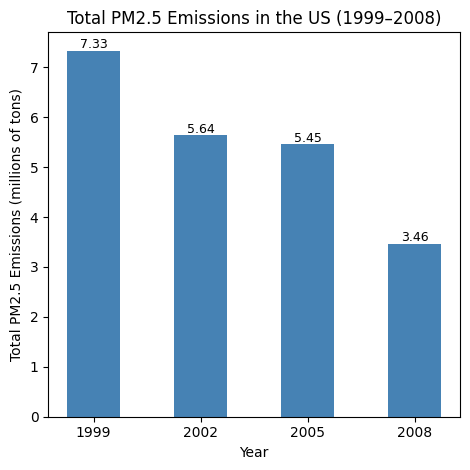

Plot 1 saved.


In [2]:
# Q1: Have total US PM2.5 emissions decreased from 1999 to 2008?
total_by_year = NEI.groupby("year")["Emissions"].sum() / 1e6  # convert to millions of tons

fig, ax = plt.subplots(figsize=(480/100, 480/100), dpi=100)
ax.bar(total_by_year.index.astype(str), total_by_year.values, color="steelblue", width=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Total PM2.5 Emissions (millions of tons)")
ax.set_title("Total PM2.5 Emissions in the US (1999–2008)")
for i, (yr, val) in enumerate(total_by_year.items()):
    ax.text(i, val + 0.05, f"{val:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("../plot1.png", dpi=100, bbox_inches="tight")
plt.show()
print("Plot 1 saved.")

## Plot 2 — Baltimore City PM2.5 Emissions (1999–2008)

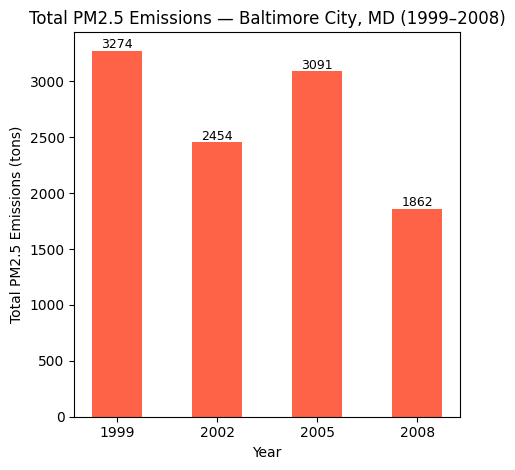

Plot 2 saved.


In [3]:
# Q2: Have Baltimore City total emissions decreased from 1999 to 2008?
baltimore = NEI[NEI["fips"] == "24510"]
baltimore_by_year = baltimore.groupby("year")["Emissions"].sum()

fig, ax = plt.subplots(figsize=(480/100, 480/100), dpi=100)
ax.bar(baltimore_by_year.index.astype(str), baltimore_by_year.values, color="tomato", width=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Total PM2.5 Emissions (tons)")
ax.set_title("Total PM2.5 Emissions — Baltimore City, MD (1999–2008)")
for i, (yr, val) in enumerate(baltimore_by_year.items()):
    ax.text(i, val + 20, f"{val:.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("../plot2.png", dpi=100, bbox_inches="tight")
plt.show()
print("Plot 2 saved.")

## Plot 3 — Baltimore City Emissions by Source Type (1999–2008)

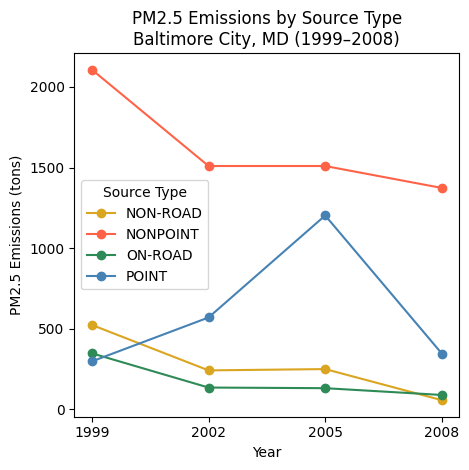

Plot 3 saved.


In [4]:
# Q3: Which source types in Baltimore City increased/decreased 1999–2008?
baltimore_type = (
    baltimore.groupby(["year", "type"])["Emissions"]
    .sum()
    .reset_index()
)

colors = {"POINT": "steelblue", "NONPOINT": "tomato", "ON-ROAD": "seagreen", "NON-ROAD": "goldenrod"}

fig, ax = plt.subplots(figsize=(480/100, 480/100), dpi=100)
for source_type, group in baltimore_type.groupby("type"):
    ax.plot(group["year"], group["Emissions"], marker="o",
            label=source_type, color=colors.get(source_type))
ax.set_xlabel("Year")
ax.set_ylabel("PM2.5 Emissions (tons)")
ax.set_title("PM2.5 Emissions by Source Type\nBaltimore City, MD (1999–2008)")
ax.legend(title="Source Type")
ax.set_xticks([1999, 2002, 2005, 2008])
plt.tight_layout()
plt.savefig("../plot3.png", dpi=100, bbox_inches="tight")
plt.show()
print("Plot 3 saved.")

## Plot 4 — US Coal Combustion Emissions (1999–2008)

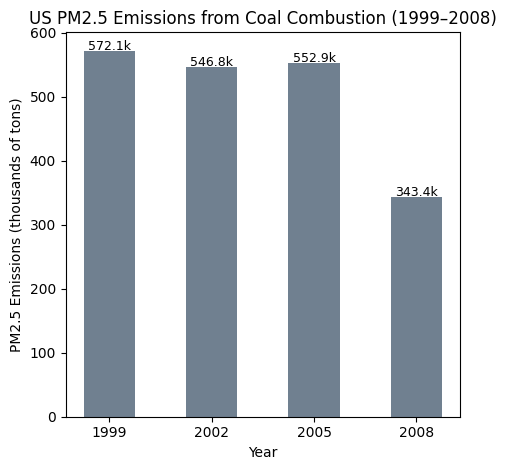

Plot 4 saved.


In [5]:
# Q4: How have coal combustion emissions changed in the US from 1999–2008?
# Filter SCC for coal combustion sources
coal_scc = SCC[
    SCC["EI.Sector"].str.contains("Coal", case=False, na=False) &
    SCC["EI.Sector"].str.contains("Comb", case=False, na=False)
]["SCC"].astype(str)

coal_nei = NEI[NEI["SCC"].astype(str).isin(coal_scc)]
coal_by_year = coal_nei.groupby("year")["Emissions"].sum() / 1e3  # thousands of tons

fig, ax = plt.subplots(figsize=(480/100, 480/100), dpi=100)
ax.bar(coal_by_year.index.astype(str), coal_by_year.values, color="slategray", width=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("PM2.5 Emissions (thousands of tons)")
ax.set_title("US PM2.5 Emissions from Coal Combustion (1999–2008)")
for i, (yr, val) in enumerate(coal_by_year.items()):
    ax.text(i, val + 1, f"{val:.1f}k", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("../plot4.png", dpi=100, bbox_inches="tight")
plt.show()
print("Plot 4 saved.")

## Plot 5 — Baltimore City Motor Vehicle Emissions (1999–2008)

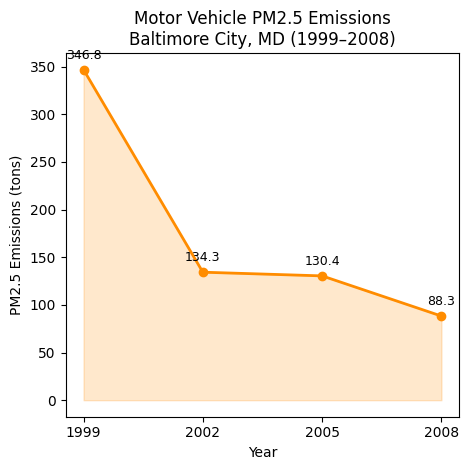

Plot 5 saved.


In [6]:
# Q5: How have motor vehicle emissions changed in Baltimore City from 1999–2008?
# Motor vehicles = ON-ROAD type
motor_baltimore = NEI[(NEI["fips"] == "24510") & (NEI["type"] == "ON-ROAD")]
motor_balt_by_year = motor_baltimore.groupby("year")["Emissions"].sum()

fig, ax = plt.subplots(figsize=(480/100, 480/100), dpi=100)
ax.plot(motor_balt_by_year.index, motor_balt_by_year.values, marker="o", color="darkorange", linewidth=2)
ax.fill_between(motor_balt_by_year.index, motor_balt_by_year.values, alpha=0.2, color="darkorange")
ax.set_xlabel("Year")
ax.set_ylabel("PM2.5 Emissions (tons)")
ax.set_title("Motor Vehicle PM2.5 Emissions\nBaltimore City, MD (1999–2008)")
ax.set_xticks([1999, 2002, 2005, 2008])
for yr, val in motor_balt_by_year.items():
    ax.annotate(f"{val:.1f}", (yr, val), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("../plot5.png", dpi=100, bbox_inches="tight")
plt.show()
print("Plot 5 saved.")

## Plot 6 — Baltimore City vs Los Angeles: Motor Vehicle Emissions (1999–2008)

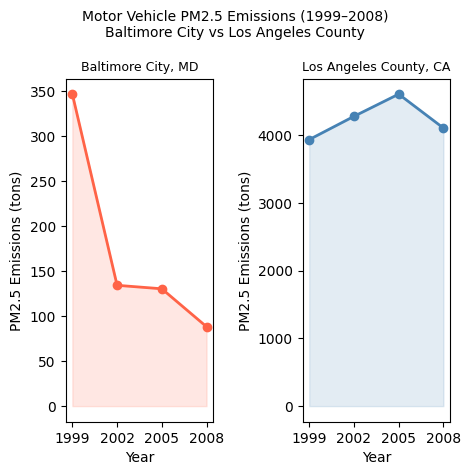

% change in motor vehicle emissions (1999 → 2008):
  Baltimore City, MD: -74.5%
  Los Angeles County, CA: 4.3%

Plot 6 saved.


In [7]:
# Q6: Baltimore City vs Los Angeles County — which saw greater change in motor vehicle emissions?
motor_both = NEI[
    (NEI["fips"].isin(["24510", "06037"])) & (NEI["type"] == "ON-ROAD")
].copy()
motor_both["City"] = motor_both["fips"].map({"24510": "Baltimore City, MD", "06037": "Los Angeles County, CA"})

# Normalize to 1999 baseline (% change) so both cities are comparable on same scale
grouped = motor_both.groupby(["City", "year"])["Emissions"].sum().reset_index()
baseline = grouped[grouped["year"] == 1999].set_index("City")["Emissions"]
grouped["PctChange"] = grouped.apply(lambda r: (r["Emissions"] / baseline[r["City"]] - 1) * 100, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(480/100, 480/100), dpi=100)

colors = {"Baltimore City, MD": "tomato", "Los Angeles County, CA": "steelblue"}

for ax, (city, group) in zip(axes, grouped.groupby("City")):
    ax.plot(group["year"], group["Emissions"], marker="o", color=colors[city], linewidth=2)
    ax.fill_between(group["year"], group["Emissions"], alpha=0.15, color=colors[city])
    ax.set_title(city, fontsize=9)
    ax.set_xlabel("Year")
    ax.set_ylabel("PM2.5 Emissions (tons)")
    ax.set_xticks([1999, 2002, 2005, 2008])

fig.suptitle("Motor Vehicle PM2.5 Emissions (1999–2008)\nBaltimore City vs Los Angeles County", fontsize=10)
plt.tight_layout()
plt.savefig("../plot6.png", dpi=100, bbox_inches="tight")
plt.show()

# Print % change summary
print("% change in motor vehicle emissions (1999 → 2008):")
for city, group in grouped.groupby("City"):
    start = group[group["year"] == 1999]["Emissions"].values[0]
    end = group[group["year"] == 2008]["Emissions"].values[0]
    print(f"  {city}: {((end/start)-1)*100:.1f}%")
print("\nPlot 6 saved.")